In [1]:
import sys,os,re
import numpy             as np
import matplotlib.pyplot as plt
import pandas            as pd
import seaborn           as sb

from source_code.mock_maker import MakeMock

from source_code.likelihood import LSSlike
from source_code.compute_obs_sources import get_obs

from cobaya.run import run

from copy import deepcopy

import matplotlib
from matplotlib import rc
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm

rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c',

yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}

In [2]:
gwspecs  = {'Nbins_GW': 6,
            'N_gw': int(1.e6),
            'sigma_eps_gw': 0.01,
            'fsky': 0.35,
            'scale_cut': {'method': 'ell_cut', 'value': 200}}

galspecs = {'fsky': 0.35,
            'Nbins_gal': 10,
            'gal_per_arcmin': 30.,
            'sigma_eps': 0.3}

fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'H0': 67.,
            'ns': 0.96,
            'logA': 3.05685,
            'a0': -0.007589,
            'a1': 0.002008,
            'a2': -0.004127,
            'a3': 0.002918,
            'a4': -0.0006784,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292,
            'b0_poly_GW': 0.830703,
            'b1_poly_GW': 1.190547,
            'b2_poly_GW': -0.928357,
            'b3_poly_GW': 0.423292,
            #'tau': 0.05,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            #MG params
            'mu0': 0.,
            'sigma0': 0.,
            'MG_flag': 1,
            'pure_MG_flag': 2,
            'musigma_par': 1,
            'DE_model': 0}

print(np.exp(fiducial['logA'])*1.e-10)

2.126048105729501e-09


In [18]:
SNR_threshold = 1

bin_to_plot = [1]

covmats_ells_toplot = [5,10]
obs_used = ['GC', 'WL', 'GWC', 'GWWL']
run_grid_test = True
test_parameter = {'name': 'a0',
                  'variation': 0.05,
                  'latex': r'$a_0$',
                  'Ngrid': 10,
                  'noiseless_like': True}

In [4]:
mock_data_path = './mock_data/new_LSS_GW_LCDM_masked'

In [20]:
observables = ['GC', 'WL', 'GWC', 'GWWL']
settings = {'obs_settings': {'extra': None,
                                 'case': 'simple',
                                 'obs_used': observables,
                                 'camb_path': '',
                                 'calculation': 'CAMB'},

                'analysis_settings': {'lmin': 10,
                                      'lmax': 1500,
                                      'Nbin_ell': 20,
                                      'galaxy_specs': galspecs,
                                      'GW_specs': gwspecs}}

In [21]:
camb_path = ''
mock = MakeMock(galspecs, gwspecs,observables,camb_path,fiducial,test_parameter,obs_used)
mock_all_obs = mock.mock_data
ells = mock_all_obs['noiseless']['ells']


Computing fiducial observables...
...done in 12.49 s


In [ ]:
cls_all_obs = get_obs(fiducial,mock.mock_data['distributions'],ells, settings['obs_settings']).Cls
settings['obs_settings']['obs_used'] = ['GC', 'WL']
cls_only_gal = get_obs(fiducial,mock.mock_data['distributions'],ells, settings['obs_settings']).Cls

In [ ]:
print(cls_all_obs['L1xL1']-cls_only_gal['L1xL1'])

In [ ]:
from matplotlib.lines import Line2D

bin_indices = [1, 3, 6]
linestyle = ['-', '--', ':']
gw_palette = ['palevioletred', 'orchid', 'darkmagenta']
cross_palette = ['lightgrey', 'grey', 'black']
gal_palette = ['blue', 'dodgerblue', 'skyblue']

subplot_titles = [
    'GCph', 'WL', 'GCph × WL',
]

title_to_obs = [
    ('G', 'G'), ('L', 'L'), ('G', 'L'),
]

ells = cls_all_obs['ells']
ell_factor = ells * (ells + 1) / (2 * np.pi)

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=False)

for i, (ax, title, (obs1, obs2)) in enumerate(zip(axs.flat, subplot_titles, title_to_obs)):
    for idx, bi in enumerate(bin_indices):
        key = obs1 + str(bi) + 'x' + obs2 + str(bi)
        if key not in cls_all_obs:
            continue


        ax.plot(
            ells,
            np.abs(cls_all_obs[key]-cls_only_gal[key])/cls_all_obs[key],
            linestyle=linestyle[idx],
            linewidth=2
        )

    ax.set_title(title, fontsize=18)
    ax.set_xscale('log')

    row, col = divmod(i, 3)
    if row == 2:
        ax.set_xlabel(r'$\ell$', fontsize=18)
    else:
        ax.set_xticklabels([])
    if col == 0:
        ax.set_ylabel(r'$C_{ii}^{A \times B}(\ell)$', fontsize = 18)
    ax.tick_params(axis='both', which='both', labelleft=True)



plt.tight_layout()



## Data to test

In [ ]:
if mock_data_path == '':
    print('Making mock data...')
    camb_path = ''
    observables = ['GC', 'WL', 'GWC', 'GWWL']
    mock = MakeMock(galspecs, gwspecs,observables,camb_path,fiducial,test_parameter, obs_used)
    mock_not_masked = mock.mock_data
    fiducial_not_masked = mock.fiducial_obs
    Cl_not_masked = mock_not_masked['noiseless']
    mock_not_masked['ells'] = mock_not_masked['noiseless']['ells']
else:
    print('Loading mock data...')
    mock_not_masked = {}
    camb_path = ''
    mock_not_masked['noiseless'] = pd.read_csv(mock_data_path+'_Cls_noiseless.dat',sep='\s+',header=0)
    mock_not_masked['noisy'] = pd.read_csv(mock_data_path+'_Cls_noisy.dat',sep='\s+',header=0)
    mock_not_masked['ells'] = mock_not_masked['noiseless']['ells']
    mock_not_masked['covmat_dict'] = np.load(mock_data_path+'_covmat.npy',allow_pickle=True).item()
    observables = ['GC', 'WL', 'GWC', 'GWWL']



In [7]:
    mock_not_masked = {}
    mock_not_masked['noiseless'] = pd.read_csv(mock_data_path+'_Cls_noiseless.dat',sep='\s+',header=0)
    mock_not_masked['noisy'] = pd.read_csv(mock_data_path+'_Cls_noisy.dat',sep='\s+',header=0)
    mock_not_masked['ells'] = mock_not_masked['noiseless']['ells']
    mock_not_masked['covmat_dict'] = np.load(mock_data_path+'_covmat.npy',allow_pickle=True).item()
    observables = ['GC', 'WL', 'GWC', 'GWWL']

In [8]:
mock_data_path = './mock_data/new_LSS_GW_LCDM_masked_Melodie'

In [9]:
    mock_not_masked_Melodie = {}
    camb_path = ''
    mock_not_masked_Melodie['noiseless'] = pd.read_csv(mock_data_path+'_Cls_noiseless.dat',sep='\s+',header=0)
    mock_not_masked_Melodie['noisy'] = pd.read_csv(mock_data_path+'_Cls_noisy.dat',sep='\s+',header=0)
    mock_not_masked_Melodie['ells'] = mock_not_masked['noiseless']['ells']
    mock_not_masked_Melodie['covmat_dict'] = np.load(mock_data_path+'_covmat.npy',allow_pickle=True).item()


In [ ]:
gwspecs  = {'Nbins_GW': 6,
            'N_gw': int(1.e6),
            'sigma_eps_gw': 0.01,
            'fsky': 0.35,
            'scale_cut': {'method': 'ell_cut', 'value': 200}}

galspecs = {'fsky': 0.35,
            'Nbins_gal': 10,
            'gal_per_arcmin': 30.,
            'sigma_eps': 0.3}

fiducial = {'ombh2': 0.022445,
            'omch2': 0.1205579307,
            'H0': 67.,
            'ns': 0.96,
            'logA': 3.05685,
            'a0': -0.007589,
            'a1': 0.002008,
            'a2': -0.004127,
            'a3': 0.0,
            'a4': -0.0,
            'b0_poly': 0.830703,
            'b1_poly': 1.190547,
            'b2_poly': -0.928357,
            'b3_poly': 0.423292,
            'b0_poly_GW': 0.830703,
            'b1_poly_GW': 1.190547,
            'b2_poly_GW': -0.928357,
            'b3_poly_GW': 0.423292,
            #'tau': 0.05,
            'w': -1.,
            'wa': 0.,
            'mnu': 0.06,
            #MG params
            'mu0': 0.,
            'sigma0': 0.,
            'MG_flag': 1,
            'pure_MG_flag': 2,
            'musigma_par': 1,
            'DE_model': 0}

print(np.exp(fiducial['logA'])*1.e-10)

In [ ]:
    camb_path = ''
    observables = ['GC', 'WL', 'GWC', 'GWWL']
    mock_IA = MakeMock(galspecs, gwspecs,observables,camb_path,fiducial,test_parameter, obs_used)
    mock_not_masked_IA = mock_IA.mock_data
    fiducial_not_masked_IA = mock_IA.fiducial_obs

In [11]:
renamed_obs = []
observables = ['GC','WL']
for obs in observables:
    if obs == 'GC':
        renamed_obs.append('G')
    elif obs == 'WL':
        renamed_obs.append('L')
    elif obs == 'GWWL':
        renamed_obs.append('WL')
    elif obs == 'GWC':
        renamed_obs.append('WC')


# MASK

In [ ]:
use_obs = ['GC', 'WL']
cov_df = mock_not_masked['covmat_dict'][str(int(mock_not_masked['ells'][0]))].copy()
cols_to_drop = [col for col in cov_df.columns if 'WC' in col or 'WL' in col]
rows_to_drop = [idx for idx in cov_df.index   if 'WC' in idx or 'WL' in idx]
mock_masked = deepcopy(mock_not_masked)
#fiducial_masked = deepcopy(fiducial_not_masked)

if not any('GW' in key for key in use_obs):
    for ell in mock_masked['ells']:
        ell_str = str(int(ell)) 
        cov_df = mock_masked['covmat_dict'][ell_str]
        cov_df = cov_df.drop(columns=cols_to_drop)
        cov_df = cov_df.drop(index=rows_to_drop)
        mock_masked['covmat_dict'][ell_str] = cov_df

#fiducial_masked = fiducial_masked.drop(columns=cols_to_drop)
#print(fiducial_masked.columns, fiducial_not_masked.columns)
mock_masked['noiseless'] = mock_masked['noiseless'].drop(columns=cols_to_drop)
Cl_masked = mock_masked['noiseless'].copy()
mock_masked['noisy'] = mock_masked['noisy'].drop(columns=cols_to_drop)


# Plot

In [ ]:
error_df_masked = pd.DataFrame({'ells': mock_masked['ells']})
for j,obs1 in enumerate(renamed_obs):
    for i,obs2 in enumerate(renamed_obs):
        if i>=j:
            for bi in bin_to_plot:
                error = []
                for ell in mock_masked['ells']:
                    ellcov = mock_masked['covmat_dict'][str(ell)]
                    error.append(np.sqrt(ellcov.at[obs1+str(bi)+'x'+obs2+str(bi),obs1+str(bi)+'x'+obs2+str(bi)]))
    
                error_df_masked[obs1+str(bi)+'x'+obs2+str(bi)] = error

In [ ]:
error_df_not_masked = pd.DataFrame({'ells': mock_not_masked['ells']})
for j,obs1 in enumerate(renamed_obs):
    for i,obs2 in enumerate(renamed_obs):
        if i>=j:
            for bi in bin_to_plot:
                error = []
                for ell in mock_not_masked['ells']:
                    ellcov = mock_not_masked['covmat_dict'][str(ell)]
                    error.append(np.sqrt(ellcov.at[obs1+str(bi)+'x'+obs2+str(bi),obs1+str(bi)+'x'+obs2+str(bi)]))
    
                error_df_not_masked[obs1+str(bi)+'x'+obs2+str(bi)] = error

In [ ]:
for ell,ind in enumerate(mock_masked['ells']):
    print(error_df_masked['G1xG1'][ell]-error_df_not_masked['G1xG1'][ell], 'G')
    print(error_df_masked['L1xL1'][ell]-error_df_not_masked['L1xL1'][ell], 'L')
    print(error_df_masked['G1xL1'][ell]-error_df_not_masked['G1xL1'][ell], 'GL')


In [ ]:
for ell,ind in enumerate(mock_masked['ells']):

    print(Cl_masked['G1xG1'][ell]-mock_not_masked['noiseless']['G1xG1'][ell], 'G')
    print(Cl_masked['L1xL1'][ell]-mock_not_masked['noiseless']['L1xL1'][ell], 'L')
    print(Cl_masked['G1xL1'][ell]-mock_not_masked['noiseless']['G1xL1'][ell], 'GL')

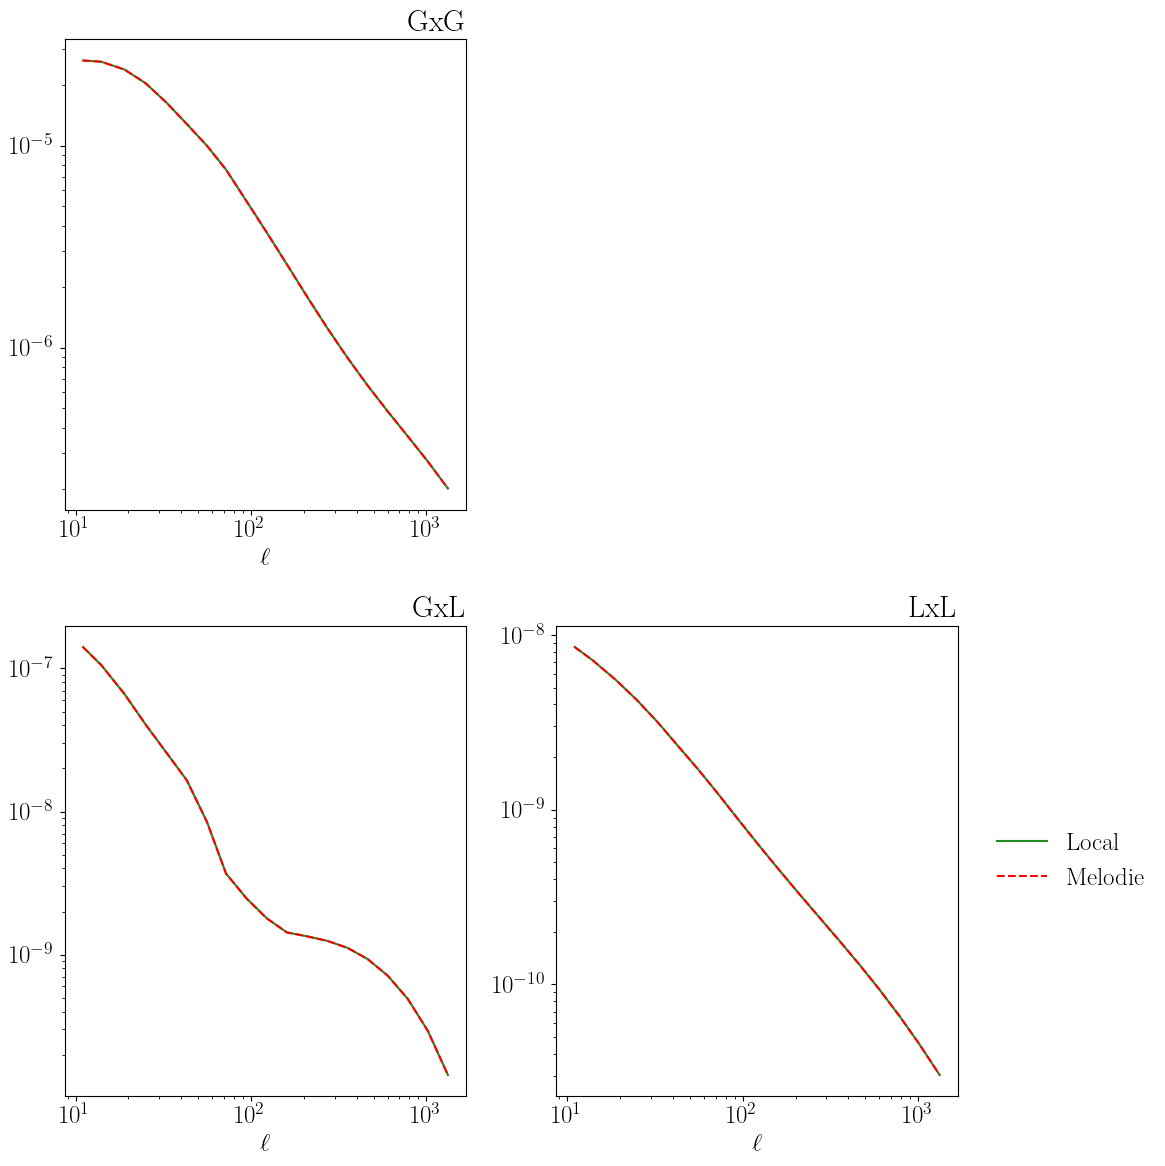

In [13]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(renamed_obs),
                              nrows=len(renamed_obs))
if len(renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])

for j,obs1 in enumerate(renamed_obs):
    for i,obs2 in enumerate(renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:

            df_masked = pd.melt(mock_not_masked['noiseless'].abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) 
                                                                                        for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
            sb.lineplot(df_masked,x='ells',y='value',hue='Bin',ax=axes[i,j],palette=['forestgreen', 'forestgreen', 'forestgreen'],legend=0, label='Local',)

            df_not_masked = pd.melt(mock_not_masked_Melodie['noiseless'].abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi)
                                                                                        for bi in bin_to_plot],
                            value_name='value',var_name='Bin')
            sb.lineplot(df_not_masked,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0,
                        palette=['red', 'red', 'red'],linestyle='--', label='Melodie')
#
            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')
            if obs1+obs2 != 'GL':
                axes[i,j].set_yscale('log')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
ax.legend(**sidelegend) 
    
plt.tight_layout();

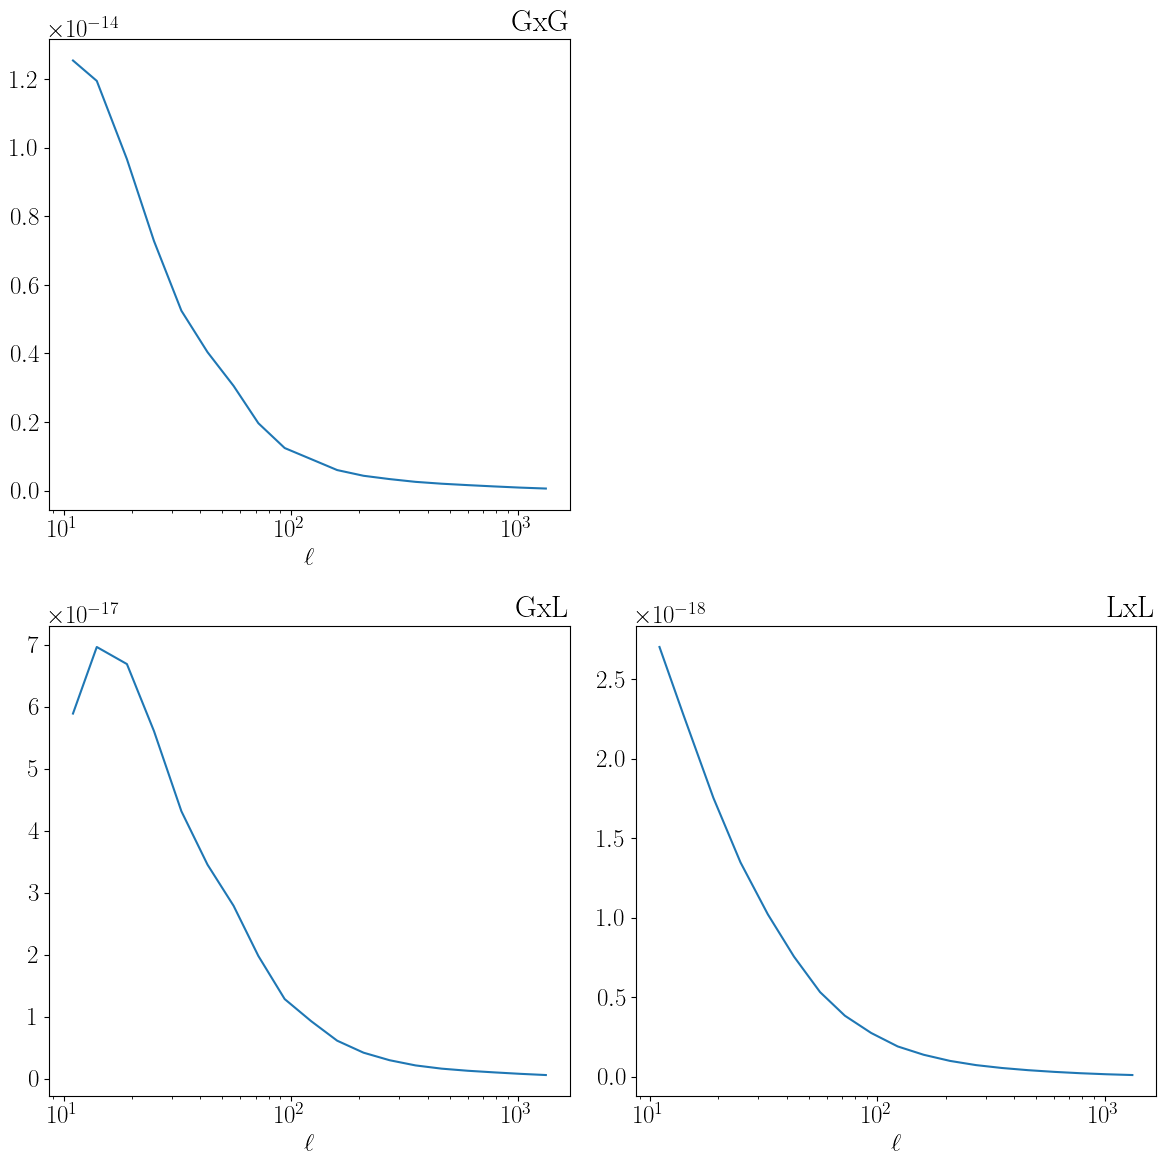

In [14]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(renamed_obs),
                              nrows=len(renamed_obs))
if len(renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])

for j,obs1 in enumerate(renamed_obs):
    for i,obs2 in enumerate(renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:
            df_masked = pd.melt(mock_not_masked['noiseless'].abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) 
                                                                                        for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
        
            df_not_masked = pd.melt(mock_not_masked_Melodie['noiseless'].abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi)
                                                                                        for bi in bin_to_plot],
                            value_name='value',var_name='Bin')
            
            df = df_masked.copy()
            df['value'] = abs((df_masked['value']-df_not_masked['value']))
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)

            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    #ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
    
plt.tight_layout();

In [ ]:
fig, temp_axes = plt.subplots(figsize=(12,12),ncols=len(renamed_obs),
                              nrows=len(renamed_obs))
if len(renamed_obs) > 1:
    axes = temp_axes
else:
    axes = np.array([[temp_axes]])

for j,obs1 in enumerate(renamed_obs):
    for i,obs2 in enumerate(renamed_obs):
        if i<j:
            axes[i,j].axis('off')
        else:
            df_masked = pd.melt(fiducial_not_masked.abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi) 
                                                                                        for bi in bin_to_plot],
                         value_name='value',var_name='Bin')
        
            df_not_masked = pd.melt(fiducial_not_masked_IA.abs(),id_vars=['ells'],value_vars=[obs1+str(bi)+'x'+obs2+str(bi)
                                                                                        for bi in bin_to_plot],
                            value_name='value',var_name='Bin')
            
            df = df_masked.copy()
            df['value'] = abs(100*(df_masked['value']-df_not_masked['value'])/df_not_masked['value'])
            sb.lineplot(df,x='ells',y='value',hue='Bin',ax=axes[i,j],legend=0)

            
            axes[i,j].set_title(obs1+'x'+obs2,loc='right')

for ax in axes.reshape(-1): 
    ax.set_xscale('log')
    #ax.set_yscale('log')
    ax.set_xlabel(r'$\ell$')
    ax.set_ylabel('')
    
plt.tight_layout();

In [ ]:
for ind,ell in enumerate(mock_masked['ells']):
    if ind in covmats_ells_toplot:

        unity = np.matmul(mock_masked['covmat_dict'][str(ell)],np.linalg.inv(mock_masked['covmat_dict'][str(ell)]))
        
        plt.figure()
        sb.heatmap(unity)#,norm=LogNorm())

In [ ]:
for ind,ell in enumerate(mock_not_masked['ells']):
    if ind in covmats_ells_toplot:

        unity = np.matmul(mock_not_masked['covmat_dict'][str(ell)],np.linalg.inv(mock_not_masked['covmat_dict'][str(ell)]))

        plt.figure()
        sb.heatmap(unity)#,norm=LogNorm())

In [ ]:
for ind,ell in enumerate(mock_masked['ells']):
    if ind in covmats_ells_toplot:

        cov_not_masked = mock_not_masked['covmat_dict'][str(int(ell))]
        cov_masked = mock_masked['covmat_dict'][str(int(ell))] 

        plt.figure(figsize=(6, 5))
        sb.heatmap(cov_not_masked-cov_masked)


In [22]:
mock_path = './mock_data/new_LSS_GW_LCDM_masked'

In [ ]:
if mock_path != '':
    mock.mock_data['noiseless'].to_csv(mock_path+'_Cls_noiseless.dat',sep='\t',header=True,float_format="%.24g")
    mock.mock_data['noisy'].to_csv(mock_path+'_Cls_noisy.dat',sep='\t',header=True,float_format="%.24g")
    np.save(mock_path+'_covmat.npy',mock.mock_data['covmat_dict'])
    np.save(mock_path+'_source_distribution.npy',mock.mock_data['distributions'])

In [23]:
from bios import read

myfid = deepcopy(mock.fiducial)
test_parameter['name'] = 'a3'
test_parameter['latex'] = r'$a_3$'
baseline = read('settings/LCDM_3x2pt_evaluate.yaml')
likesets = deepcopy(baseline['likelihood']['LSS'])
baseline['likelihood']['LSS']['external']   = LSSlike
baseline['likelihood']['LSS']['data_path']  = likesets['data_path']
baseline['likelihood']['LSS']['debug_mode'] = False
if 'GWC' in baseline['likelihood']['LSS']['settings']['obs_used'] :
    for ind in range(4):
        baseline['params']['b{}_poly_GW'.format(ind)] = baseline['params']['b{}_poly'.format(ind)]

free_pars = [par for par,val in baseline['params'].items() if type(val)==dict and 'prior' in val.keys()]

eval_dict = {}
for par,val in myfid.items():
    if par not in free_pars:
        baseline['params'][par] = val
    else:
        eval_dict[par] = val

baseline['sampler'] = {'evaluate': {'override': eval_dict}}


In [24]:
if run_grid_test:
    test_par_vec = np.linspace(baseline['params'][test_parameter['name']]['prior']['min'], baseline['params'][test_parameter['name']]['prior']['max'], 10)
    # (mock.fiducial[test_parameter['name']]*(1-test_parameter['variation']),
    #                            mock.fiducial[test_parameter['name']]*(1+test_parameter['variation']),
    #                            test_parameter['Ngrid'])
    
    if fiducial[test_parameter['name']] not in test_par_vec:
        test_par_vec = np.append(test_par_vec,fiducial[test_parameter['name']])
    
    baseline['likelihood']['LSS']['use_noiseless_cls'] = test_parameter['noiseless_like']
    
    dfs = []
    
    for val in test_par_vec:
        eval_dict[test_parameter['name']] = val
        baseline['sampler'] = {'evaluate': {'override': eval_dict}}
        updated_info, sampler = run(baseline)
    
        dfs.append(pd.DataFrame({test_parameter['latex']: val,
                                 r'$\chi^2$': -2*sampler.logposterior.loglike},index=[0]))
    
    chi2_df = pd.concat(dfs,ignore_index=True)

Covmats inverted in 0.556
[evaluate] Initialized!
[evaluate] Looking for a reference point with non-zero prior.
[evaluate] Reference point:
   ombh2 = 0.022445
   omch2 = 0.120558
   ns = 0.96
   H0 = 67
   logA = 3.05685
   a0 = -0.007589
   a1 = 0.002008
   a2 = -0.004127
   a3 = -0.0089
   a4 = -0.0006784
   b0_poly = 0.830703
   b1_poly = 1.19055
   b2_poly = -0.928357
   b3_poly = 0.423292
[evaluate] Evaluating prior and likelihoods...
[evaluate] log-posterior  = -794937
[evaluate] log-prior      = 43.1307
[evaluate]    logprior_0 = 43.1307
[evaluate] log-likelihood = -794980
[evaluate]    chi2_LSS = 1.58996e+06
[evaluate] Derived params:
[evaluate]    As = 2.12605e-09
[evaluate]    omegab = 0.05
[evaluate]    omegam = 0.319998
Covmats inverted in 0.921
[evaluate] Initialized!
[evaluate] Looking for a reference point with non-zero prior.
[evaluate] Reference point:
   ombh2 = 0.022445
   omch2 = 0.120558
   ns = 0.96
   H0 = 67
   logA = 3.05685
   a0 = -0.007589
   a1 = 0.002008


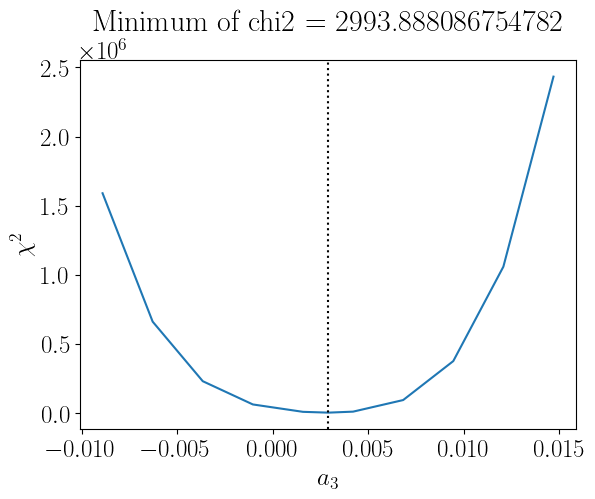

In [25]:
if run_grid_test:
    plt.figure()
    plt.title('Minimum of chi2 = {}'.format(chi2_df['$\chi^2$'].min()))
    sb.lineplot(chi2_df,x=test_parameter['latex'],y=r'$\chi^2$')
    plt.axvline(x=mock.fiducial[test_parameter['name']],ls=':',color='black');